In [1]:
import pandas as pd

from metrics import load_validation_data

In [64]:
validation_data = load_validation_data()
validation_data["gadm"] = validation_data.name.apply(lambda name: name[4:])
len(validation_data)

3435

In [69]:
pd.crosstab(validation_data.name, validation_data.reference, margins=True)

reference,cloud,dry,unknown,wet,All
name,,,,,
dry_land,82,870,57,3,1012
dry_ocean,389,0,27,565,981
wet_land,25,26,67,341,459
wet_ocean,91,3,146,743,983
All,587,899,297,1652,3435


In [72]:
validation_data = validation_data[validation_data.reference != "unknown"]
validation_data
mixed_cm = pd.crosstab(validation_data.name, validation_data.reference)

In [73]:
# user's accuracy
users = pd.DataFrame.from_dict(
    {
        name: (mixed_cm.loc[name, name[0:3]] / mixed_cm.loc[name].sum()).round(2) * 100
        for name in mixed_cm.index
    },
    orient="index",
    columns=["user's accuracy"],
)

users

,user's accuracy
dry_land,91.0
dry_ocean,0.0
wet_land,87.0
wet_ocean,89.0


In [74]:
(
    (validation_data.reference == "cloud").sum() / validation_data.reference.count()
).round(3) * 100

18.7

In [75]:
wet_dry_cm = pd.crosstab(validation_data.wofl, validation_data.reference)
wet_dry_cm

reference,cloud,dry,wet
wofl,,,
dry,471,870,568
wet,116,29,1084


In [76]:
inland_data = validation_data[validation_data.gadm == "land"]
inland_cm = pd.crosstab(inland_data.wofl, inland_data.reference)
inland_cm

reference,cloud,dry,wet
wofl,,,
dry,82,870,3
wet,25,26,341


In [85]:
(validation_data.wofl == validation_data.reference).mean().round(3) * 100

62.3

In [84]:
(inland_data.wofl == inland_data.reference).mean().round(3) * 100

89.9

In [78]:
def users_accuracy(cm, name="user's accuracy"):
    return pd.DataFrame.from_dict(
        {
            name: (cm.loc[name, name] / cm.loc[name].sum()).round(3) * 100
            for name in cm.index
        },
        orient="index",
        columns=[name],
    )


def producers_accuracy(cm, name="producers's accuracy"):
    return pd.DataFrame.from_dict(
        {
            name: (cm.loc[name, name] / cm.loc[:, name].sum()).round(3) * 100
            for name in cm.index
        },
        orient="index",
        columns=[name],
    )


combined_users = users_accuracy(wet_dry_cm)
combined_producers = producers_accuracy(wet_dry_cm)
inland_users = users_accuracy(inland_cm, "inland user's accuracy")
inland_producers = producers_accuracy(inland_cm, "inland producers's accuracy")

pd.concat([combined_users, combined_producers, inland_users, inland_producers], axis=1)

,user's accuracy,producers's accuracy,inland user's accuracy,inland producers's accuracy
dry,45.6,96.8,91.1,97.1
wet,88.2,65.6,87.0,99.1


In [10]:
pd.crosstab(validation_data.name, validation_data.reference, normalize="index").round(2)

reference,cloud,dry,wet
name,,,
dry_land,0.09,0.91,0.00
dry_ocean,0.41,0.00,0.59
wet_land,0.06,0.07,0.87
wet_ocean,0.11,0.00,0.89


In [33]:
land_only = validation_data[validation_data.name.isin(["dry_land", "wet_land"])]
pd.crosstab(land_only.name, land_only.reference, normalize="index").round(2)

reference,cloud,dry,wet
name,,,
dry_land,0.09,0.91,0.00
wet_land,0.06,0.07,0.87


In [87]:
validation_data["order"] = validation_data.modified_time.factorize()[0] + 1
validation_data["acc"] = validation_data.wofl == validation_data.reference

In [88]:
import plotnine as pn

acc_by_tile = validation_data.groupby("order").agg({"acc": ["mean", "sum", "count"]})
acc_by_tile.columns = ["_".join(col) for col in acc_by_tile.columns]

acc_by_tile = acc_by_tile.reset_index().assign(
    cum_sum=acc_by_tile.acc_sum.cumsum(),
    cum_count=acc_by_tile.acc_count.cumsum(),
    cum_acc=lambda x: x.cum_sum / x.cum_count,
)

acc_by_tile

,order,acc_mean,acc_sum,acc_count,cum_sum,cum_count,cum_acc
0,1,0.813187,74,91,NaN,NaN,NaN
1,2,0.568182,50,88,74.0,91.0,0.813187
2,3,0.616438,45,73,124.0,179.0,0.692737
3,4,0.589041,43,73,169.0,252.0,0.670635
4,5,0.661972,47,71,212.0,325.0,0.652308
5,6,0.731959,71,97,259.0,396.0,0.654040
6,7,0.687500,55,80,330.0,493.0,0.669371
7,8,0.637681,44,69,385.0,573.0,0.671902
8,9,0.311688,24,77,429.0,642.0,0.668224
9,10,0.733333,66,90,453.0,719.0,0.630042


/home/jesse/Projects/D4D/dep-wofs/venv/lib/python3.10/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


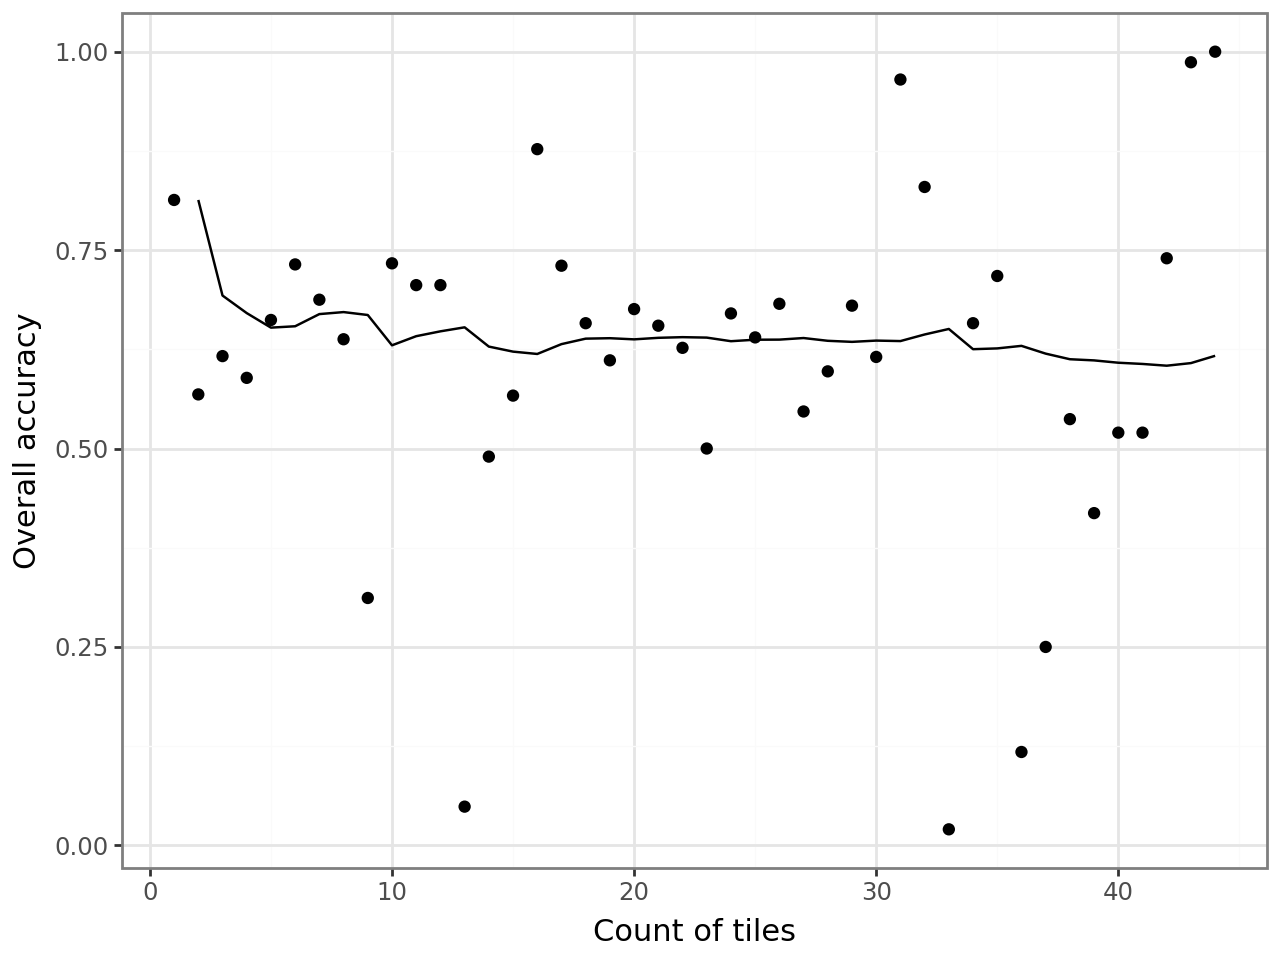

In [89]:
(
    pn.ggplot(acc_by_tile, pn.aes(x="order"))
    + pn.geom_point(pn.aes(y="acc_mean"))
    + pn.geom_line(pn.aes(y="cum_acc"))
    + pn.xlab("Count of tiles")
    + pn.ylab("Overall accuracy")
    + pn.theme_bw()
)